# Assignment 1 — Machine Learning Foundations Review

## The scenario

You're a data scientist at a manufacturer running a fleet of industrial
milling machines. Right now, maintenance happens on a fixed schedule,
regardless of how a given machine is actually doing. That has two costs:
machines that are fine get pulled in and serviced too early, wasting time
and money, and machines that are quietly heading toward failure sometimes
don't make it to their scheduled check — which means an unplanned stop on
the production line, and possibly a more expensive repair than if it had
been caught early.

Each machine streams sensor data continuously — temperature, rotational
speed, torque, how long the current tool has been in use. The idea is to
use that data to predict which machines are actually at risk of failing
soon, so maintenance can be scheduled based on real condition instead of
a calendar. That's the general shape of a predictive maintenance problem,
and it's a good one to practice on: the features are physically
meaningful (you can reason about *why* a model flags a machine, not just
trust the number), the target is a clean binary outcome, and the stakes
of getting it wrong in either direction are easy to make concrete — a
missed failure can stop a production line, a false alarm costs an
unnecessary service call.

You'll work with the **AI4I 2020 Predictive Maintenance Dataset**, a
public benchmark of 10,000 records from machines like these, with
features including air and process temperature, rotational speed,
torque, tool wear, and a machine type/quality variant, plus a binary
`Machine failure` label. Only a small fraction of the machines in the
dataset actually failed — keep that in mind once you start evaluating
models, since a model that always predicts "no failure" will already
look deceptively accurate.

## What this assignment is (and isn't)

This isn't new material — you already know how linear/logistic
regression, decision trees, random forests, and XGBoost work. This is a
review: get your hands back on the tools, rebuild the muscle memory of
fitting and comparing these models, and practice reasoning about the
trade-offs between them (accuracy vs. interpretability, training cost,
how each one behaves as data changes), using a dataset and a scenario
that look like something a real team would actually have to maintain —
which is exactly the theme the rest of this course builds on.

## How to use this notebook

This is a working template, not a fill-in-the-blank form — the `# TODO`
cells are where you write real code, and the questions in the markdown
cells are meant to be answered in a sentence or two, right there in the
notebook, in your own words. There's no single correct answer for most
of the reflection questions; what matters is that your answer is backed
by what you actually found, not by which model sounds the most advanced.

**Before you start:** download the AI4I 2020 Predictive Maintenance
Dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset)
(or Kaggle) and place the CSV next to this notebook. Update `DATA_PATH`
below if you name it something else.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import src.config as cfg
importlib.reload(cfg)

df = pd.read_csv(cfg.ASSETS_DIR / "data.csv")
df = df[cfg.IMPORTANT_COLUMNS].copy()

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## Part 1 — Look at the data before you model it

1. Check basic shape, dtypes, and missing values.
2. Plot the class balance for `Machine failure`. What percentage of rows are actual failures?
3. Pick two or three sensor variables (e.g. torque, tool wear) and compare their distributions for failed vs. non-failed machines.
4. Decide how you'll split the data (train/test) — and whether you should stratify by the target. Write one sentence on why that choice matters here.

In [12]:
# TODO: shape, dtypes, missing values
# 1. Shape (Número de linhas e colunas)
print("Shape:", df.shape)

# 2. Dtypes (Tipos de variáveis)
print("\nDtypes:")
print(df.dtypes)

# 3. Missing values (Contagem de valores nulos)
print("\nMissing Values:")
print(df.isnull().sum())


Shape: (10000, 7)

Dtypes:
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
dtype: object

Missing Values:
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64


Taxa de falha: 3.39%


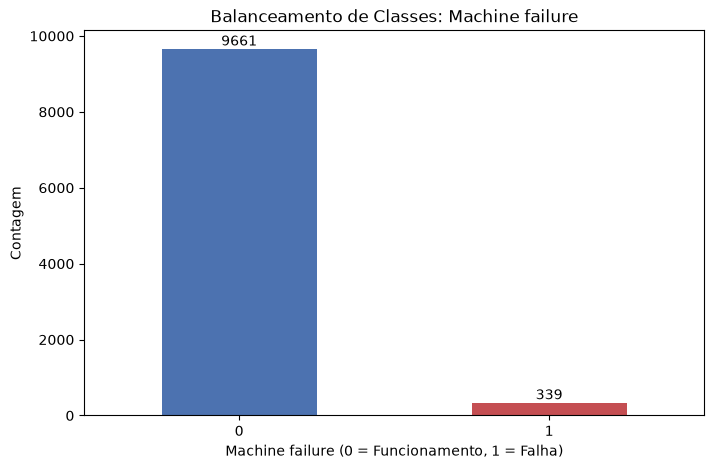

In [13]:
# TODO: plot class balance for Machine failure, and print the failure rate
# Calcular e exibir a taxa de falha (assumindo que a coluna seja 0 e 1)
failure_rate = df['Machine failure'].mean() * 100
print(f"Taxa de falha: {failure_rate:.2f}%")

# Plotar o balanceamento de classes
plt.figure(figsize=(8, 5))
ax = df['Machine failure'].value_counts().plot(kind='bar', color=['#4C72B0', '#C44E52'])

plt.title('Balanceamento de Classes: Machine failure')
plt.xlabel('Machine failure (0 = Funcionamento, 1 = Falha)')
plt.ylabel('Contagem')
plt.xticks(rotation=0)

# Adicionar os valores em cima das barras para melhor visualização
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

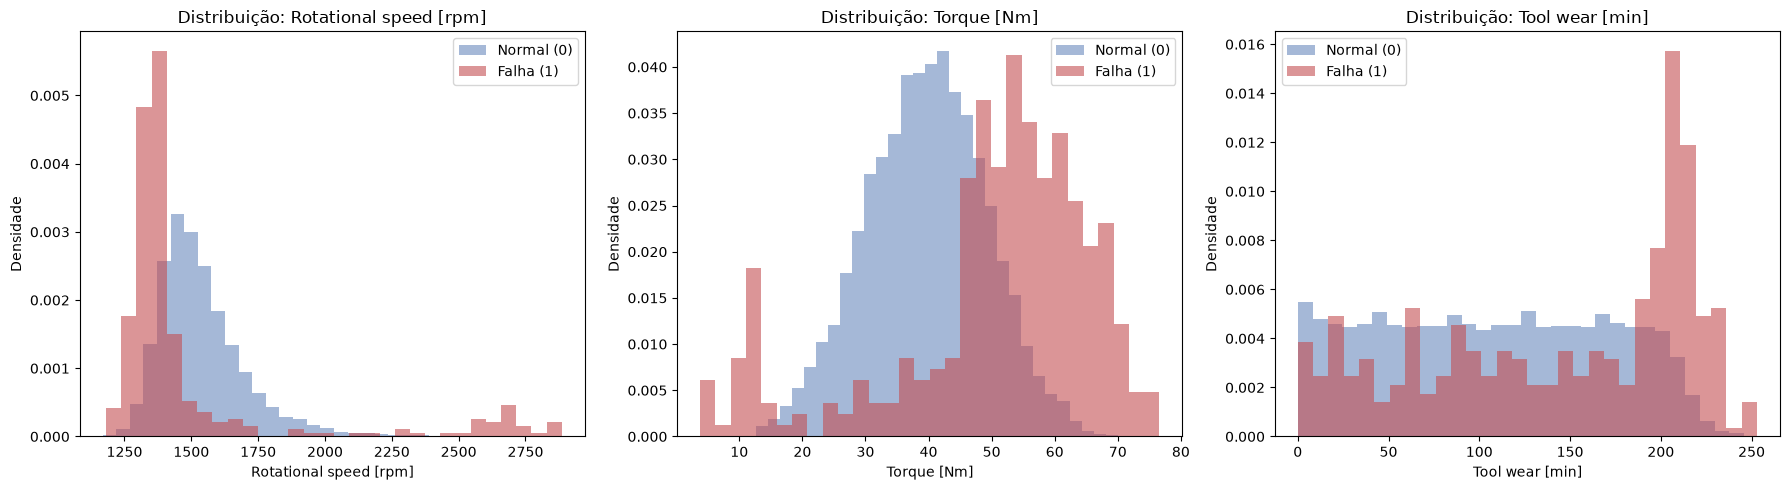

In [14]:
# TODO: compare distributions of 2-3 sensor variables, failed vs. non-failed
# Escolha 2 a 3 variáveis contínuas (sensores) para comparar
# Ajuste os nomes abaixo conforme as colunas presentes no seu df
sensor_vars = ['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Criar a figura para os subplots
fig, axes = plt.subplots(1, len(sensor_vars), figsize=(18, 5))

for i, col in enumerate(sensor_vars):
    if col in df.columns:
        # Separar os dados por classe
        normal_data = df[df['Machine failure'] == 0][col]
        failed_data = df[df['Machine failure'] == 1][col]
        
        # Plotar histogramas (com transparência/alpha para visualizar sobreposição)
        axes[i].hist(normal_data, bins=30, alpha=0.5, label='Normal (0)', color='#4C72B0', density=True)
        axes[i].hist(failed_data, bins=30, alpha=0.6, label='Falha (1)', color='#C44E52', density=True)
        
        axes[i].set_title(f'Distribuição: {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Densidade')
        axes[i].legend()
    else:
        axes[i].set_title(f'{col} não encontrada')

plt.tight_layout()
plt.show()

In [15]:
# 1. Identificar quais colunas são do tipo 'object' ou 'string'
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print("Colunas categóricas identificadas:", categorical_cols)

# 2. Aplicar o get_dummies nessas colunas
# O drop_first=True remove a primeira categoria gerada para evitar multicolinearidade linear
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Verificar o novo formato do DataFrame
print("\nNovo shape do dataset:", df.shape)

# Visualizar as primeiras linhas para conferir as novas colunas geradas
df.head()

Colunas categóricas identificadas: ['Type']

Novo shape do dataset: (10000, 8)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [16]:
from sklearn.model_selection import train_test_split

# 1. Separar as features (X) da variável alvo (y)
X = df.drop(columns=['Machine failure'])
y = df['Machine failure']

# 2. Fazer o split de 20% para teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

# 3. Conferir os resultados
print(f"Tamanho do Treino: X={X_train.shape}, y={y_train.shape}")
print(f"Tamanho do Teste:  X={X_test.shape}, y={y_test.shape}")

# Confirmando que o estratificado funcionou (a taxa deve ser igual nos dois)
print(f"\nTaxa de falha no Treino: {y_train.mean():.4f}")
print(f"Taxa de falha no Teste:  {y_test.mean():.4f}")

Tamanho do Treino: X=(8000, 7), y=(8000,)
Tamanho do Teste:  X=(2000, 7), y=(2000,)

Taxa de falha no Treino: 0.0339
Taxa de falha no Teste:  0.0340


**Your notes on Part 1** (what did you notice, and how will it affect your modeling choices?)

*Write your answer here.*

## Part 2 — Baseline: logistic regression

1. Fit a logistic regression predicting `Machine failure` from the sensor features.
2. Report precision, recall, F1, and ROC-AUC — not just accuracy. Why would accuracy alone mislead you here?
3. Look at the model's coefficients. Which features push the prediction toward "failure"? Does that match physical intuition?
4. Try moving the classification threshold away from 0.5. What happens to recall and precision? Which direction would you move it if a missed failure is far more costly than a false alarm?

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Inicializar o modelo com balanceamento de classes
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 2. Treinar o modelo
lr_model.fit(X_train, y_train)

# 3. Fazer previsões no conjunto de teste
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1] # Probabilidades para o ROC-AUC

# 4. Calcular métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 5. Exibir os resultados
print("--- Métricas do Modelo ---")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Métricas do Modelo ---
ROC-AUC:   0.9069
Precision: 0.1440
Recall:    0.8235
F1-Score:  0.2451

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000



--- Coeficientes do Modelo (Ordenados por Impacto) ---
                   Feature  Coefficient
1  Process temperature [K]    -1.009738
0      Air temperature [K]     0.951648
5                   Type_L     0.489397
3              Torque [Nm]     0.239986
6                   Type_M     0.017740
4          Tool wear [min]     0.013608
2   Rotational speed [rpm]     0.009556


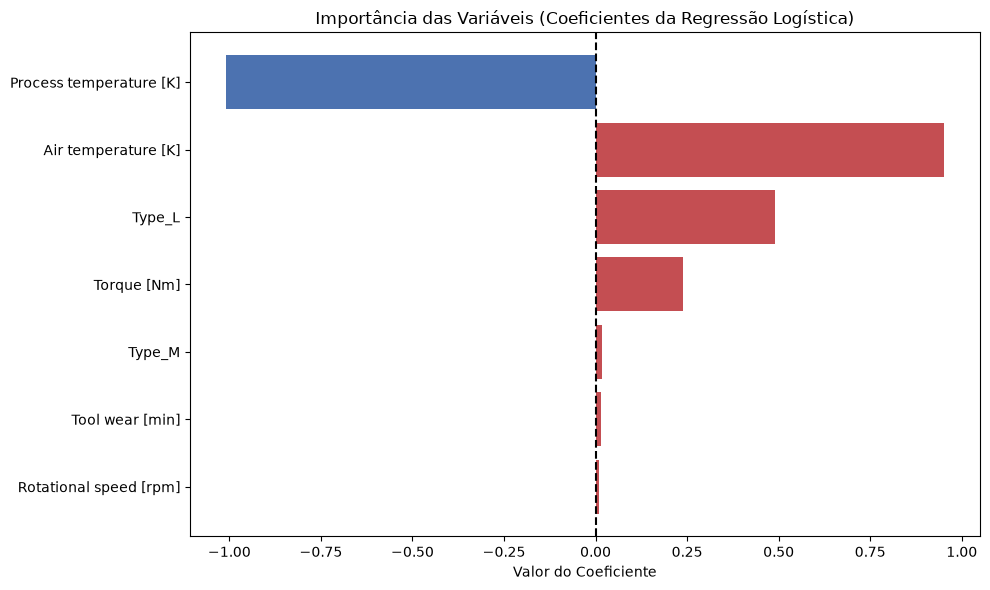

In [18]:
# TODO: inspect the model's coefficients — which features matter most, and in which direction?
# 1. Extrair os nomes das features e os coeficientes do modelo
features = X_train.columns
coefs = lr_model.coef_[0]

# 2. Criar um DataFrame para facilitar a visualização
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs
})

# 3. Criar uma coluna com o valor absoluto para ordenar pela "importância"
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Exibir a tabela ordenada
print("--- Coeficientes do Modelo (Ordenados por Impacto) ---")
print(coef_df[['Feature', 'Coefficient']].head(10)) # Mostrando os 10 mais importantes

# 4. Plotar os coeficientes para visualização
plt.figure(figsize=(10, 6))
# Reordenar para o plot (os maiores em cima)
coef_df_plot = coef_df.head(15).sort_values(by='Abs_Coefficient', ascending=True)

# Cores: vermelho para positivo (aumenta risco), azul para negativo (diminui risco)
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df_plot['Coefficient']]

plt.barh(coef_df_plot['Feature'], coef_df_plot['Coefficient'], color=colors)
plt.title('Importância das Variáveis (Coeficientes da Regressão Logística)')
plt.xlabel('Valor do Coeficiente')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

--- Trade-off: Precision vs Recall ---
 Threshold  Precision  Recall  F1-Score
       0.1     0.0534  0.9853    0.1013
       0.2     0.0718  0.9559    0.1336
       0.3     0.0925  0.9265    0.1682
       0.4     0.1153  0.8971    0.2044
       0.5     0.1440  0.8235    0.2451
       0.6     0.1775  0.7647    0.2881
       0.7     0.2400  0.7059    0.3582
       0.8     0.3115  0.5588    0.4000
       0.9     0.4182  0.3382    0.3740


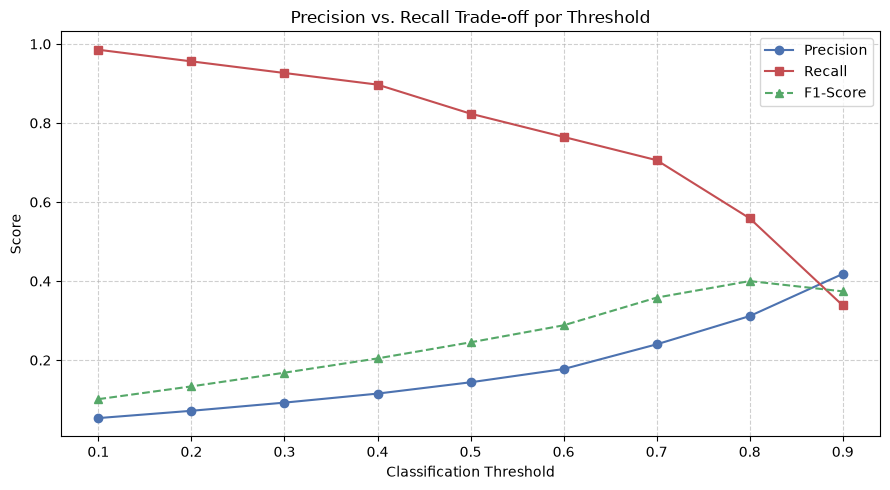

In [19]:
# TODO: sweep a few classification thresholds and show how precision/recall trade off
# Definir uma lista de thresholds para testar
thresholds = np.arange(0.1, 1.0, 0.1)

# Listas para guardar as métricas
precisions = []
recalls = []
f1_scores = []

# Iterar sobre cada threshold
for t in thresholds:
    # Converter probabilidades em predições binárias baseadas no threshold
    y_pred_t = (y_pred_proba >= t).astype(int)
    
    # Calcular métricas (zero_division=0 evita warnings se não houver previsões positivas)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

# 1. Criar um DataFrame para exibir os resultados de forma tabular
tradeoff_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

print("--- Trade-off: Precision vs Recall ---")
print(tradeoff_df.round(4).to_string(index=False))

# 2. Plotar o gráfico do Trade-off
plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, marker='o', label='Precision', color='#4C72B0')
plt.plot(thresholds, recalls, marker='s', label='Recall', color='#C44E52')
plt.plot(thresholds, f1_scores, marker='^', label='F1-Score', color='#55A868', linestyle='--')

plt.title('Precision vs. Recall Trade-off por Threshold')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.xticks(thresholds)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Part 3 — Decision tree

1. Fit a decision tree classifier on the same features and split.
2. Compare precision, recall, F1, and ROC-AUC against the logistic regression.
3. Visualize the top two or three levels of the tree. Which feature does it split on first — does that match what the logistic regression suggested?
4. Train one tree with no depth limit and one with a small `max_depth` (e.g. 3–4). Compare train vs. test performance for both. What does this tell you about overfitting?

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Inicializar o modelo com class_weight='balanced' conforme combinado
# Adicionado max_depth=5 para evitar overfitting extremo e permitir a visualização
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

# 2. Treinar o modelo
dt_model.fit(X_train, y_train)

# 3. Fazer previsões no conjunto de teste
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# 4. Calcular métricas
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

# 5. Exibir os resultados
print("--- Métricas do Modelo: Árvore de Decisão ---")
print(f"ROC-AUC:   {roc_auc_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_dt))


--- Métricas do Modelo: Árvore de Decisão ---
ROC-AUC:   0.9079
Precision: 0.3109
Recall:    0.8824
F1-Score:  0.4598

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.31      0.88      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.91      0.71      2000
weighted avg       0.97      0.93      0.95      2000



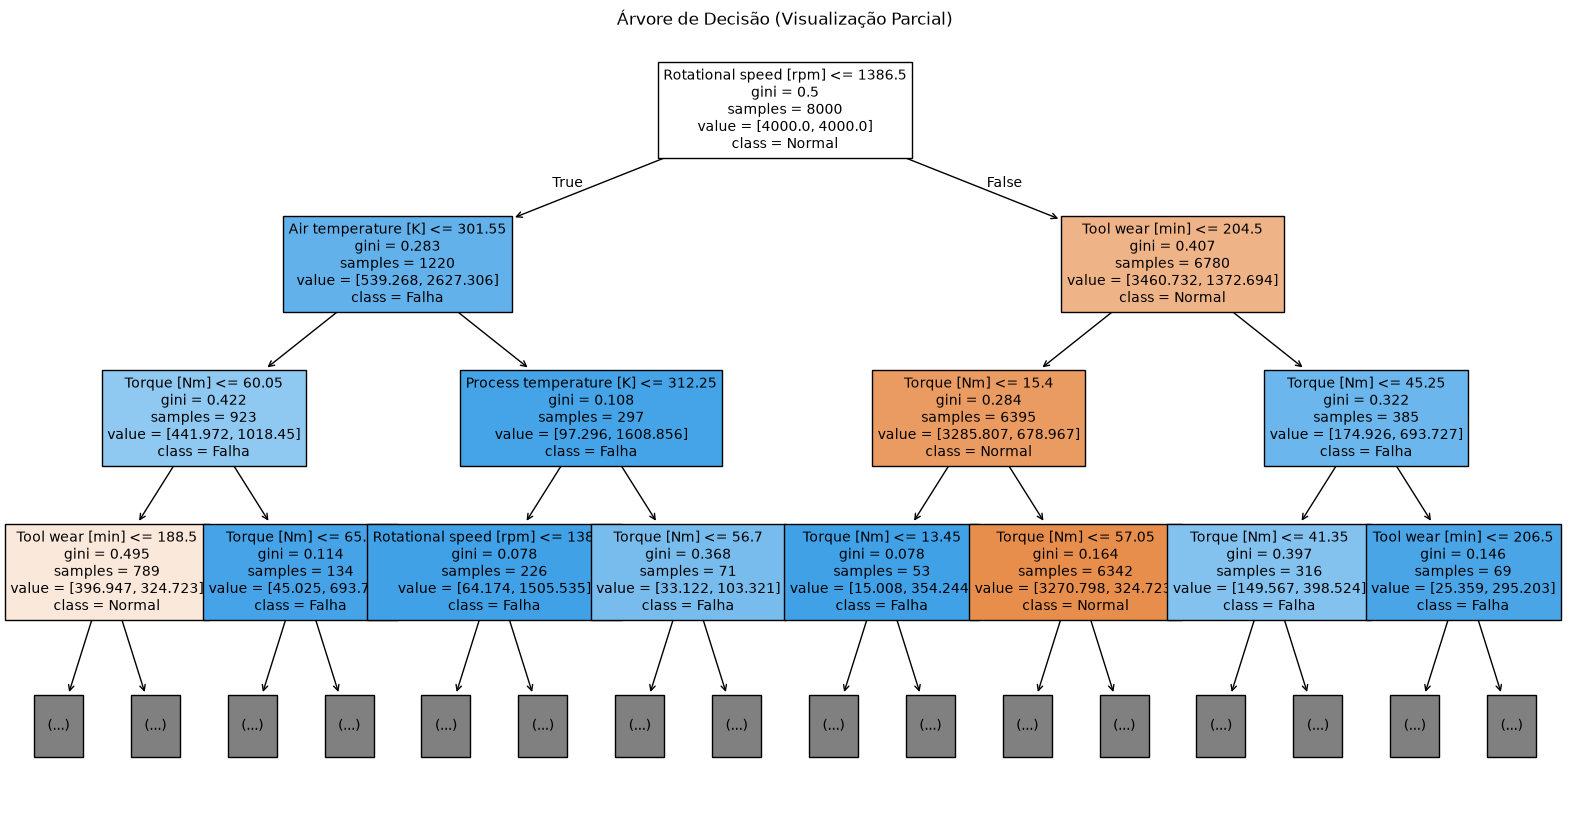

In [21]:
# TODO: visualize the top few levels of the tree
# 6. Plotar a árvore (exibindo apenas as primeiras camadas para não poluir visualmente)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train.columns, 
          class_names=['Normal', 'Falha'], 
          filled=True, 
          max_depth=3, # Limita a plotagem a 3 níveis de profundidade
          fontsize=10)
plt.title("Árvore de Decisão (Visualização Parcial)")
plt.show()

In [22]:
# TODO: compare an unlimited-depth tree vs. a shallow tree on train vs. test performance
# 1. Inicializar os dois modelos
# Árvore Ilimitada (vai crescer até classificar todas as amostras perfeitamente)
tree_unlimited = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Árvore Rasa (limitada a 3 níveis de profundidade)
tree_shallow = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)

# 2. Treinar ambos os modelos
tree_unlimited.fit(X_train, y_train)
tree_shallow.fit(X_train, y_train)

# 3. Criar uma função rápida para extrair e comparar o F1-Score (Treino vs Teste)
def evaluate_overfitting(model, name):
    # Previsões e métricas no conjunto de TREINO
    y_train_pred = model.predict(X_train)
    f1_train = f1_score(y_train, y_train_pred)
    
    # Previsões e métricas no conjunto de TESTE
    y_test_pred = model.predict(X_test)
    f1_test = f1_score(y_test, y_test_pred)
    
    return {
        'Modelo': name,
        'Profundidade Real': model.tree_.max_depth,
        'F1-Score (Treino)': round(f1_train, 4),
        'F1-Score (Teste)': round(f1_test, 4),
        'Queda de Desempenho': round(f1_train - f1_test, 4)
    }

# 4. Compilar e exibir os resultados
results = [
    evaluate_overfitting(tree_unlimited, "Árvore Ilimitada"),
    evaluate_overfitting(tree_shallow, "Árvore Rasa (max_depth=3)")
]

df_results = pd.DataFrame(results)
print("--- Comparação de Overfitting: Árvore Ilimitada vs Rasa ---")
print(df_results.to_string(index=False))

--- Comparação de Overfitting: Árvore Ilimitada vs Rasa ---
                   Modelo  Profundidade Real  F1-Score (Treino)  F1-Score (Teste)  Queda de Desempenho
         Árvore Ilimitada                 17             1.0000            0.6614               0.3386
Árvore Rasa (max_depth=3)                  3             0.3982            0.3554               0.0428


## Part 4 — Random forest

1. Fit a random forest (start around 100–200 trees) and compare its metrics against the single decision tree.
2. Plot feature importances. Does the ranking agree with the single tree and the logistic regression?
3. Vary the number of trees (e.g. 10, 50, 200, 500) and plot how test performance changes. Where does adding more trees stop helping?
4. In two or three sentences, explain — using what you actually observed — why a random forest tends to generalize better than a single tree.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# 1. Inicializar o modelo Random Forest com balanceamento de classes
rf_model = RandomForestClassifier(
    n_estimators=100,         # Número de árvores na floresta
    class_weight='balanced',  # Tratamento do desbalanceamento
    random_state=42,
    n_jobs=-1                 # Usa todos os núcleos do processador para acelerar o treino
)

# 2. Treinar o modelo
rf_model.fit(X_train, y_train)

# 3. Fazer previsões no conjunto de teste
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 4. Calcular métricas
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

# 5. Exibir os resultados
print("--- Métricas do Modelo: Random Forest ---")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))

--- Métricas do Modelo: Random Forest ---
ROC-AUC:   0.9598
Precision: 0.7344
Recall:    0.6912
F1-Score:  0.7121

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.73      0.69      0.71        68

    accuracy                           0.98      2000
   macro avg       0.86      0.84      0.85      2000
weighted avg       0.98      0.98      0.98      2000



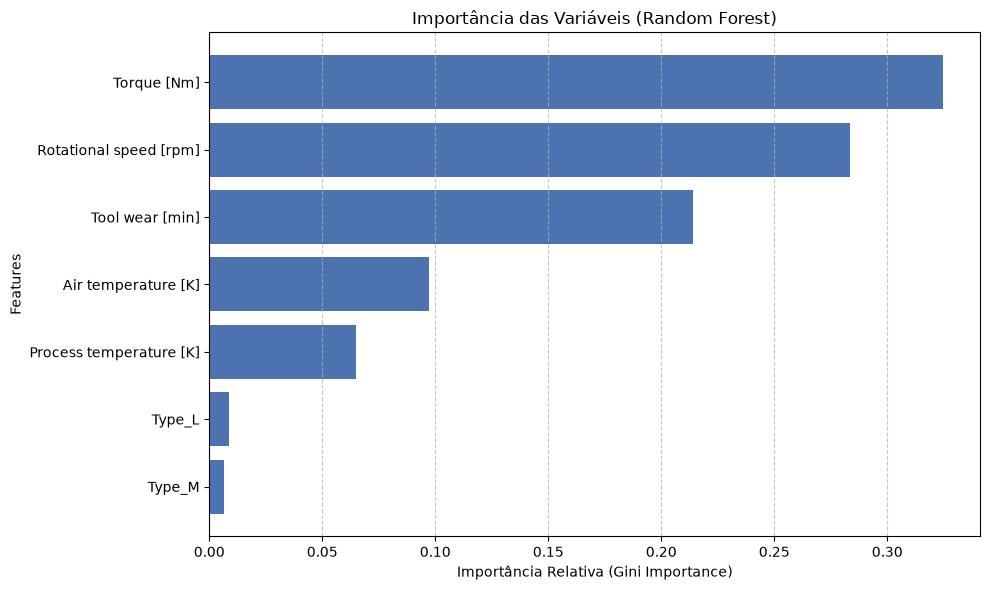

In [24]:
# TODO: plot feature importances
# 1. Extrair a importância das features do modelo Random Forest
importances = rf_model.feature_importances_
features = X_train.columns

# 2. Criar um DataFrame para organizar os dados
rf_importances = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# 3. Ordenar os valores para o plot (ordem crescente para o barh ficar com o maior no topo)
rf_importances = rf_importances.sort_values(by='Importance', ascending=True)

# 4. Plotar a importância das variáveis
plt.figure(figsize=(10, 6))
plt.barh(rf_importances['Feature'], rf_importances['Importance'], color='#4C72B0')

plt.title('Importância das Variáveis (Random Forest)')
plt.xlabel('Importância Relativa (Gini Importance)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Treinando modelos... Isso pode levar alguns segundos.


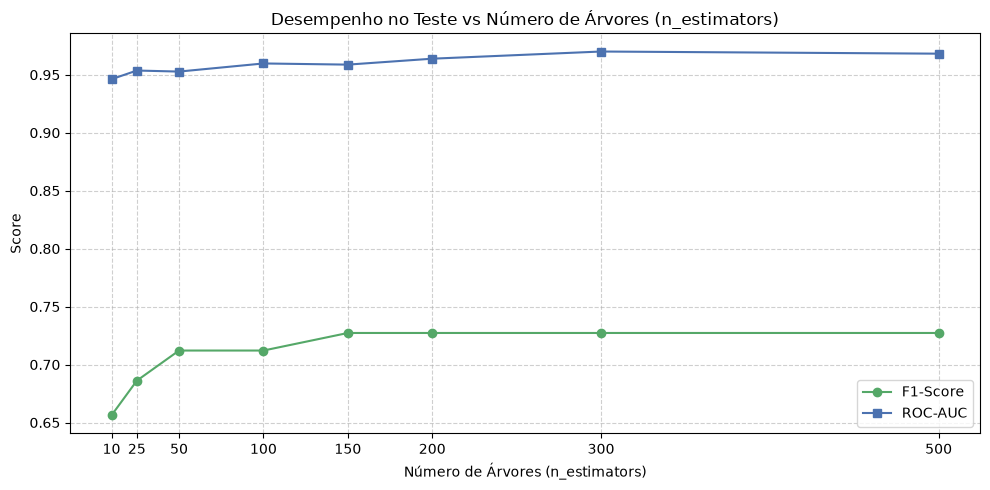

In [25]:
# TODO: vary n_estimators and plot test performance vs. number of trees
# 1. Definir uma lista de valores para n_estimators
n_trees_list = [10, 25, 50, 100, 150, 200, 300, 500]

# Listas para armazenar as métricas
f1_scores = []
auc_scores = []

print("Treinando modelos... Isso pode levar alguns segundos.")

# 2. Iterar sobre os valores e treinar um modelo para cada um
for n in n_trees_list:
    # Inicializa e treina o modelo
    rf = RandomForestClassifier(
        n_estimators=n, 
        class_weight='balanced', 
        random_state=42, 
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    # Faz previsões
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]
    
    # Calcula e armazena as métricas
    f1_scores.append(f1_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))

# 3. Plotar os resultados
plt.figure(figsize=(10, 5))
plt.plot(n_trees_list, f1_scores, marker='o', label='F1-Score', color='#55A868')
plt.plot(n_trees_list, auc_scores, marker='s', label='ROC-AUC', color='#4C72B0')

plt.title('Desempenho no Teste vs Número de Árvores (n_estimators)')
plt.xlabel('Número de Árvores (n_estimators)')
plt.ylabel('Score')
plt.xticks(n_trees_list) # Força o eixo x a mostrar exatamente os valores testados
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Your notes on Part 4** (why does a random forest generalize better than one tree — based on what you saw, not the textbook definition)

*Write your answer here.*

## Part 5 — XGBoost

1. Fit an XGBoost classifier on the same data. Given the class imbalance, look into `scale_pos_weight` (or your library's equivalent) and try it with and without.
2. Compare metrics against all three previous models, and note training time for each.
3. Plot feature importance from XGBoost and compare against the random forest's ranking.
4. Do a small hyperparameter sweep (learning rate and number of estimators are a good pair) — did tuning meaningfully change performance on this dataset, or were the gains marginal?

In [26]:
import xgboost as xgb
import re

# 1. Limpar os nomes das colunas (removendo [, ] e <)
X_train.columns = X_train.columns.str.replace(r'[\[\]<]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<]', '', regex=True)

# 2. Calcular o scale_pos_weight (total de casos normais / total de falhas)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Valor calculado para scale_pos_weight: {pos_weight:.2f}\n")

# 3. Inicializar os dois modelos
xgb_unbalanced = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_balanced = xgb.XGBClassifier(scale_pos_weight=pos_weight, random_state=42, eval_metric='logloss')

# 4. Treinar os modelos
xgb_unbalanced.fit(X_train, y_train)
xgb_balanced.fit(X_train, y_train)

# 5. Função auxiliar para calcular e printar as métricas
def evaluate_xgb(model, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"--- Métricas do Modelo: {model_name} ---")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}\n")

# 6. Avaliar e comparar os resultados
evaluate_xgb(xgb_unbalanced, "XGBoost (Sem Peso / Default)")
evaluate_xgb(xgb_balanced, "XGBoost (Com scale_pos_weight)")

Valor calculado para scale_pos_weight: 28.52

--- Métricas do Modelo: XGBoost (Sem Peso / Default) ---
ROC-AUC:   0.9729
Precision: 0.8909
Recall:    0.7206
F1-Score:  0.7967

--- Métricas do Modelo: XGBoost (Com scale_pos_weight) ---
ROC-AUC:   0.9656
Precision: 0.7391
Recall:    0.7500
F1-Score:  0.7445



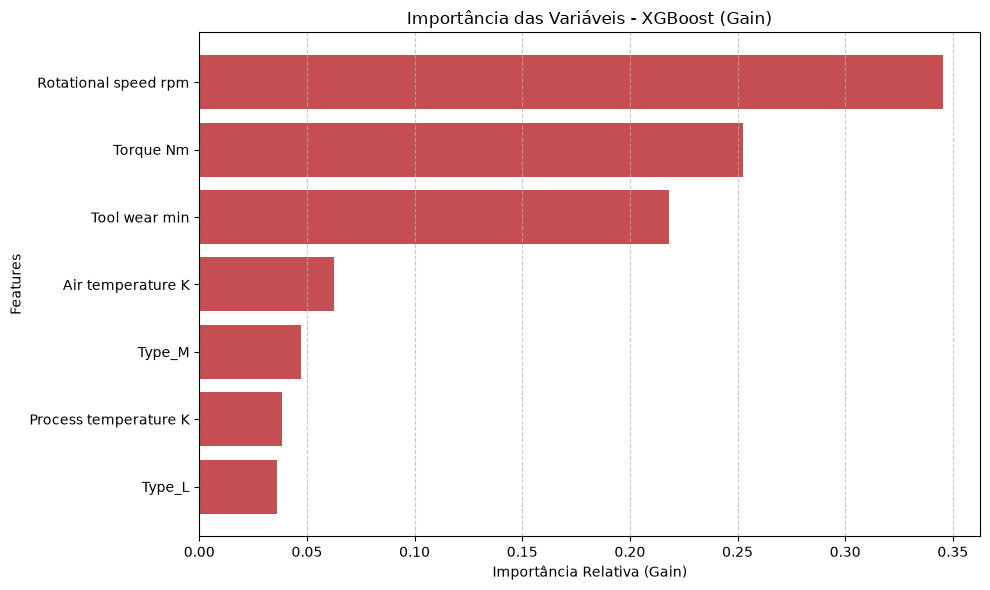

In [27]:
# TODO: plot XGBoost feature importance and compare to the random forest's
# 1. Extrair as importâncias do modelo XGBoost balanceado
xgb_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_balanced.feature_importances_
})

# 2. Ordenar os valores para o gráfico (ordem crescente)
xgb_importances = xgb_importances.sort_values(by='Importance', ascending=True)

# 3. Plotar a importância das variáveis
plt.figure(figsize=(10, 6))
plt.barh(xgb_importances['Feature'], xgb_importances['Importance'], color='#C44E52')

plt.title('Importância das Variáveis - XGBoost (Gain)')
plt.xlabel('Importância Relativa (Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
# TODO: small hyperparameter sweep (e.g. learning_rate x n_estimators) — is the gain worth it?
from sklearn.model_selection import GridSearchCV
import time

# 1. Definir as opções que queremos testar
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3], # Taxa de aprendizado
    'n_estimators': [50, 100, 200]     # Número de árvores
}

# 2. Configurar a busca (GridSearchCV)
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(scale_pos_weight=pos_weight, random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='f1',       # Foca no F1-score por conta do desbalanceamento
    cv=3,               # Cross-validation com 3 folds
    n_jobs=-1,          # Usa todos os núcleos
    verbose=1           # Mostra o progresso
)

# 3. Rodar a busca e medir o tempo
print("Iniciando a busca de hiperparâmetros...")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

print(f"\nTempo total da busca: {end_time - start_time:.2f} segundos.")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")

# 4. Avaliar o modelo vencedor no conjunto de Teste
best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)
y_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("\n--- Métricas do Modelo: XGBoost (Tuned) ---")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")

Iniciando a busca de hiperparâmetros...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Tempo total da busca: 3.98 segundos.
Melhores parâmetros encontrados: {'learning_rate': 0.1, 'n_estimators': 200}

--- Métricas do Modelo: XGBoost (Tuned) ---
ROC-AUC:   0.9748
Precision: 0.7361
Recall:    0.7794
F1-Score:  0.7571


## Part 6 — Comparison and reflection

Pull your results into one table: model, precision, recall, F1, ROC-AUC, training time.

In [29]:
# TODO: build a comparison table across all four models


**Reflection** (about a page, right here):

- Which model actually performed best, and by how much? Was the gap large enough to matter, or within noise?
- If you were handing this model to the maintenance team tomorrow, which one would you ship, and why? Think about interpretability, training/inference cost, and how easy it would be to retrain later.
- Predictive maintenance data changes over time — new machines, recalibrated sensors, seasonal shifts. Which of your four models do you think would be easiest to monitor for that kind of change, and which the hardest? You don't need to implement anything here, just reason about it.

*Write your answer here.*

## Stretch challenge: deploy it, then watch it break (optional, not graded)

If Parts 1–6 were a warm-up, this is the part that actually resembles the job.

This reuses the Docker + Flask setup from Tutorial 2 — same files, same
`docker build` / `docker run` workflow — extended with one new endpoint
so you can score a whole batch of readings in one request, the way you
did in Tutorial 2's Exercise B.

You've been given four files alongside this notebook:
- `app.py` — a Flask app with a `/predict` endpoint (one reading) and a `/predict-batch` endpoint (many readings at once). It expects a `model.pkl` file next to it.
- `Dockerfile` and `requirements.txt` — same structure as Tutorial 2.
- `run.sh` — starts the API. Unlike Tutorial 2, it does *not* train a model first; you already did that in Parts 1–6, so make sure `model.pkl` exists before you build the image.
- `future_batch.csv` — three months of sensor readings and logged outcomes that came in after "deployment."

**Steps:**

1. Save your best model from Part 6 as `model.pkl`: `joblib.dump(best_model, "model.pkl")`. Put it in the same folder as `app.py`, `Dockerfile`, `requirements.txt`, and `run.sh`.
2. Build and run the container, exactly like Tutorial 2:
   ```
   docker build -t predictive-maintenance-app .
   docker run -p 8000:8000 predictive-maintenance-app
   ```
3. Test it with curl (see the docstring at the top of `app.py` for exact examples), or adapt your `test_client.py` from Tutorial 2 to hit `/predict` with one reading.
4. Load `future_batch.csv`, send the whole thing to `/predict-batch` in one request (a list of reading dicts under a `"readings"` key — see `app.py`), and compute the same metrics you used in Part 6 from the response.
5. Compare those numbers to your original held-out test results from Part 6. Something will be off.
6. Before you go hunting for bugs in your code, look at the data itself. For each feature, compare its distribution in `future_batch.csv` against your original training data (histograms are enough to start; if you want something more quantitative, look into two-sample statistical tests for comparing distributions).
7. Write up: what changed, how you found it, and what you'd want in place *before* deployment — not after — to catch this automatically next time.

There's no single expected answer. What matters is whether you go looking at the data instead of just re-tuning the model.

In [30]:
import joblib

# TODO: save your best Part 6 model as model.pkl, in the same folder as app.py
joblib.dump(best_xgb, cfg.RESULTS_DIR /"model.pkl")


['C:\\Users\\thale\\Desktop\\UC\\master-projects\\LAIA\\results\\model.pkl']

In [31]:
# TODO: build and run the container (run these in a terminal, not this notebook):
#   docker build -t predictive-maintenance-app .
#   docker run -p 8000:8000 predictive-maintenance-app
#
# Then confirm it's alive, e.g. from this notebook:
import requests

payload = {
    "Type": "M", 
    "Air temperature [K]": 300.5, 
    "Process temperature [K]": 310.2,
    "Rotational speed [rpm]": 1450, 
    "Torque [Nm]": 42.1, 
    "Tool wear [min]": 120
}

resposta = requests.post("http://localhost:8000/predict", json=payload)
print(resposta.json())


{'failure_probability': 0.0012, 'prediction': 0}


In [32]:
future = pd.read_csv(cfg.ASSETS_DIR / "test.csv")

# TODO: send the whole batch to http://localhost:8000/predict-batch as
# {"readings": [...]} (a list of dicts — see app.py for the exact fields),
# then use the response to report precision, recall, F1, and ROC-AUC,
# the same way you did in Part 6

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# 1. Preparar os dados no formato esperado pela API {"readings": [{...}, {...}]}
# O método to_dict(orient="records") converte cada linha do DataFrame num dicionário
payload = {
    "readings": future.to_dict(orient="records")
}

# 2. Enviar a requisição para o endpoint de batch
print("A enviar lote para a API...")
resposta = requests.post("http://localhost:8000/predict-batch", json=payload)

# 3. Verificar se a requisição foi bem sucedida e calcular as métricas
if resposta.status_code == 200:
    dados_api = resposta.json()
    
    # Extrair as previsões geradas pela API
    y_pred_api = dados_api["predictions"]
    y_proba_api = dados_api["failure_probabilities"]
    
    # Extrair os rótulos reais do CSV para comparar (assumindo a coluna 'Machine failure')
    y_true = future["Machine failure"]
    
    # Calcular as métricas
    roc_auc = roc_auc_score(y_true, y_proba_api)
    precision = precision_score(y_true, y_pred_api)
    recall = recall_score(y_true, y_pred_api)
    f1 = f1_score(y_true, y_pred_api)
    
    # Exibir os resultados
    print("\n--- Métricas do Lote Futuro (Via API Docker) ---")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
else:
    print(f"Erro na API! Código de estado: {resposta.status_code}")
    print(resposta.text)

A enviar lote para a API...

--- Métricas do Lote Futuro (Via API Docker) ---
ROC-AUC:   0.7645
Precision: 0.3606
Recall:    0.4175
F1-Score:  0.3870


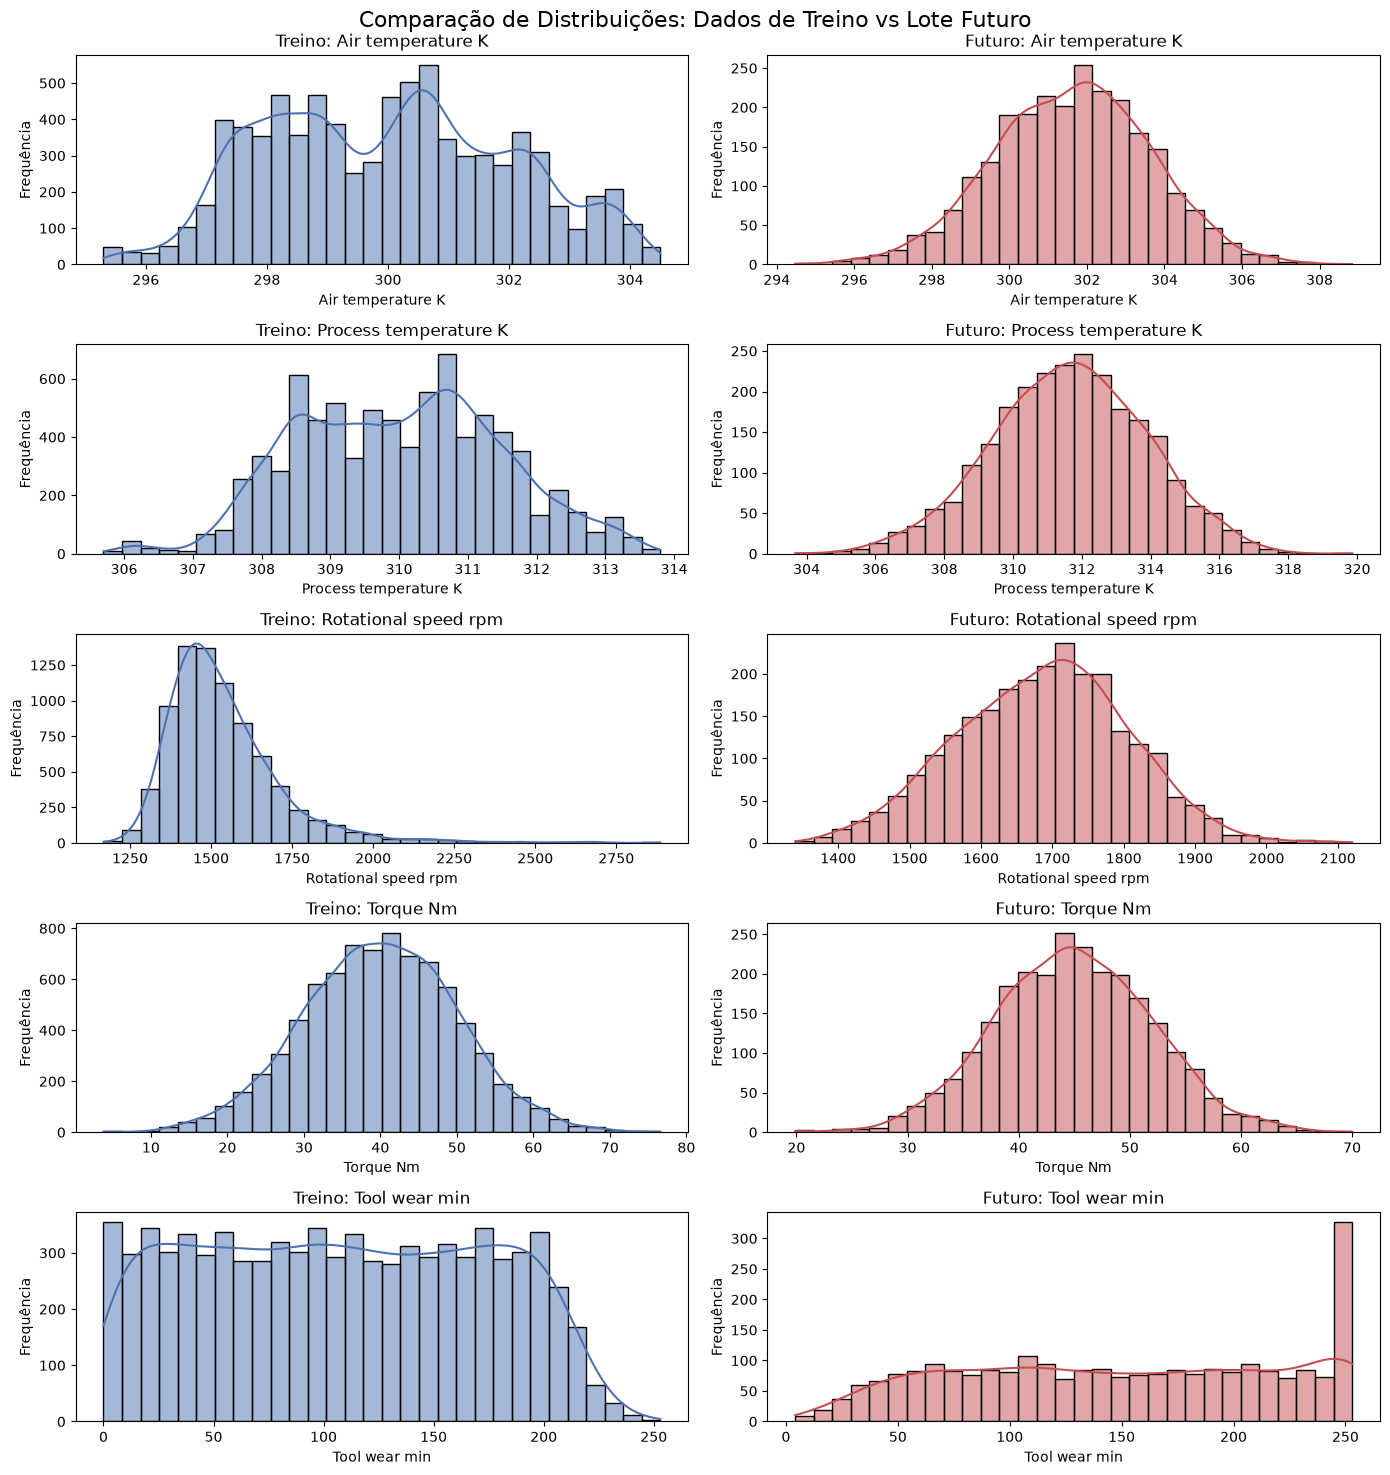

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Limpar os nomes das colunas do dataset futuro para garantir que coincidem com o X_train
future_clean = future.copy()
future_clean.columns = future_clean.columns.str.replace(r'[\[\]<]', '', regex=True)

# 2. Definir as variáveis numéricas que queremos comparar
numeric_features = [
    "Air temperature K",
    "Process temperature K",
    "Rotational speed rpm",
    "Torque Nm",
    "Tool wear min"
]

# 3. Configurar a figura (5 linhas de variáveis, 2 colunas: Treino | Futuro)
fig, axes = plt.subplots(nrows=len(numeric_features), ncols=2, figsize=(14, 15))
fig.suptitle('Comparação de Distribuições: Dados de Treino vs Lote Futuro', fontsize=16)

for i, col in enumerate(numeric_features):
    # Lado Esquerdo: Distribuição nos dados de Treino
    sns.histplot(X_train[col], bins=30, kde=True, ax=axes[i, 0], color='#4C72B0')
    axes[i, 0].set_title(f'Treino: {col}')
    axes[i, 0].set_ylabel('Frequência')
    
    # Lado Direito: Distribuição no Lote Futuro (future_batch.csv)
    sns.histplot(future_clean[col], bins=30, kde=True, ax=axes[i, 1], color='#C44E52')
    axes[i, 1].set_title(f'Futuro: {col}')
    axes[i, 1].set_ylabel('Frequência')

plt.tight_layout()
plt.subplots_adjust(top=0.95) # Dá espaço para o título principal não sobrepor os gráficos
plt.show()

**Your write-up:**

*What changed? How did you find it? What would you put in place to catch this automatically next time?*

*Write your answer here.*